# KLASIFIKASI KUALITAS UDARA KOTA-KOTA BESAR DENGAN MODEL DECISION TREE
---

## Anggota Kelompok

1. **Riyan Naffa Nusafara** (23/516897/TK/56833)
2. **Fadel Aulia Naldi** ()

## Overview

### Topic Overview

Topik yang kami angkat adalah pengukuran kualitas udara pada kota-kota besar dengan *feature* berupa polutan-polutan udara, antara lain $\text{PM}_{2.5}$, $\text{PM}_{10}$, $\text{O}_{3}$, $\text{NO}_{2}$, $\text{SO}_{2}$, dan $\text{CO}$ serta *target* berupa penilaian kualitas udara yang terdiri atas tiga kelas: *normal*, *elevated*, dan *spiked*. *Normal* merupakan keadaan udara dengan polutan di bawah tingkat bahaya, *elevated* merupakan keadaan udara dengan polutan berada pada tingkat bahaya, dan *spiked* merupakan keadaan udara dengan tingkat polutan yang sangat berbahaya.

### Dataset Overview

Setiap file CSV, yang merupakan data kualitas udara dari kota-kota di dunia, memiliki beberapa kolom:

| location_id | location_name | parameter | value | unit | datetimeUtc | datetimeLocal | timezone | latitude | longitude | country_iso | isMobile | isMonitor | owner_name | provider |

Kolom-kolom seperti `country_iso`, `isMobile`, `isMonitor`, `owner_name`, dan `provider` tidak dibutuhkan dalam analisis sehingga dapat dihilangkan.

Kolom `parameter` berisi polutan-polutan udara atau kondisi udara lainnya. Supaya model klasifikasi dapat berjalan dan dilatih, *dataset* perlu diubah menjadi *wide format*, yakni nilai dari satu parameter atau polutan mengisi satu kolom. Mengubah data menjadi *wide format* dilakukan pada bagian [pemrosesan data](#Data-Preprocessing-1).

Kolom `parameter` yang akan dianalisis antara lain `pm25`, `pm10`, `o3`, `no2`, dan `so2`. Nilai `parameter` lainnya dapat dihilangkan.

Import pandas untuk manipulasi data dan os untuk mengambil data dari *directory*.

In [1]:
import pandas as pd
import os

In [2]:
# Tentukan path ke direktori data
data_dir = "../data/"

# List seluruh file .csv
files = os.listdir(data_dir)
print(f"Files in {data_dir}: {files}\n\n")

# Ambil nama kota dengan menghilangkan akhiran .csv
cities = [file[:-4] for file in files if file.endswith('.csv')]

Files in ../data/: ['Depok.csv', 'Hanoi.csv', 'London.csv', 'Madrid.csv', 'Napoli.csv', 'New Delhi.csv', 'New Jersey.csv', 'Paris.csv', 'Riverside.csv']




In [3]:
# Loop untuk setiap kota dan baca file CSV
for city in cities:
    print(f"\n========== City: {city} ==========\n")
    # Baca file CSV
    # Gunakan try-except untuk menangani kesalahan saat membaca file
    try:
        # Baca file CSV dengan parameter datetimeUtc sebagai datetime
        df = pd.read_csv(os.path.join(data_dir, f"{city}.csv"), parse_dates=['datetimeUtc'])
        df['datetimeUtc'] = pd.to_datetime(df['datetimeUtc'])
        
        # Tampilkan parameter berbeda pada setiap kota
        print(f"{city} parameter counts:\n", df['parameter'].value_counts(), "\n")
        print("Unique parameter: ", df['parameter'].unique())

        # Tampilkan deskripsi data dan statistik dasar
        print(f"Shape of the dataset: {df.shape}")
        print("Columns in the dataset:", df.columns)
        print("Data types:\n", df.dtypes)
        print("Missing values:\n", df.isnull().sum())
        print("Basic statistics:\n", df.describe())
        
        # Tampilkan 5 baris acak dari dataset
        print("5 random rows:\n", df.sample(5))
        
    except Exception as e:
        # Jika terjadi kesalahan, tampilkan pesan kesalahan
        print(f"Error processing {city}: {e}")


========== City: Depok ==========

Depok parameter counts:
 parameter
pm1                 1000
pm10                1000
pm25                1000
relativehumidity    1000
temperature         1000
um003               1000
Name: count, dtype: int64 

Unique parameter:  ['pm1' 'pm10' 'pm25' 'relativehumidity' 'temperature' 'um003']
Shape of the dataset: (6000, 15)
Columns in the dataset: Index(['location_id', 'location_name', 'parameter', 'value', 'unit',
       'datetimeUtc', 'datetimeLocal', 'timezone', 'latitude', 'longitude',
       'country_iso', 'isMobile', 'isMonitor', 'owner_name', 'provider'],
      dtype='object')
Data types:
 location_id                    int64
location_name                 object
parameter                     object
value                        float64
unit                          object
datetimeUtc      datetime64[ns, UTC]
datetimeLocal                 object
timezone                      object
latitude                     float64
longitude                

## Data Preprocessing 1

Menghapus kolom-kolom yang tidak relevan dan melakukan pemisahan kolom bagi `parameter`.

In [4]:
# Path ke direktori data
data_dir = "../data/"

# List seluruh file .csv
files = os.listdir(data_dir)
print(f"Files in {data_dir}: {files}\n\n")

# Ambil nama kota dengan menghilangkan akhiran .csv
cities = [file[:-4] for file in files if file.endswith('.csv')]

# Daftar kolom yang akan dihapus
columns_to_drop = ['provider', 'owner_name', 'isMonitor', 'isMobile', 'country_iso']

for city in cities:
    print(f"========== City: {city} ==========\n")
    try:
        df = pd.read_csv(os.path.join(data_dir, f"{city}.csv"), parse_dates=['datetimeUtc'])
        df.drop(columns=columns_to_drop, inplace=True, errors='ignore')
        df['datetimeUtc'] = pd.to_datetime(df['datetimeUtc'])
        
        # Pivot tabel untuk memecah nilai unik parameter menjadi kolom-kolom yang berbeda
        # dengan index berupa datetime 
        df_wide = df.pivot_table(index=['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude'],
                                 columns='parameter', 
                                 values='value').reset_index()

        print(f"Shape of the dataset: {df_wide.shape}")
        print("Columns in the dataset:", df_wide.columns)
        print("Data types:\n", df_wide.dtypes)
        print("Missing values:\n", df_wide.isnull().sum())
        print("Basic statistics:\n", df_wide.describe())
        
        # Tampilkan 5 baris acak dari dataset
        print("5 random rows:\n", df.sample(5))
        
        # Set datetime sebagai index
        df_wide['datetimeUtc'] = pd.to_datetime(df_wide['datetimeUtc'])
        df_wide.set_index('datetimeUtc', inplace=False)
        
        # Simpan dataframe ke file CSV pada direktori ../data_processed/
        data_processed_dir = "../data_processed/"
        os.makedirs(data_processed_dir, exist_ok=True)
        df_wide.to_csv(os.path.join(data_processed_dir, f"{city}_processed.csv"), index=False)

    except Exception as e:
        print(f"Could not process file {city}.csv: {e}")

Files in ../data/: ['Depok.csv', 'Hanoi.csv', 'London.csv', 'Madrid.csv', 'Napoli.csv', 'New Delhi.csv', 'New Jersey.csv', 'Paris.csv', 'Riverside.csv']


========== City: Depok ==========

Shape of the dataset: (2309, 11)
Columns in the dataset: Index(['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude',
       'pm1', 'pm10', 'pm25', 'relativehumidity', 'temperature', 'um003'],
      dtype='object', name='parameter')
Data types:
 parameter
location_id                       int64
location_name                    object
datetimeUtc         datetime64[ns, UTC]
latitude                        float64
longitude                       float64
pm1                             float64
pm10                            float64
pm25                            float64
relativehumidity                float64
temperature                     float64
um003                           float64
dtype: object
Missing values:
 parameter
location_id            0
location_name          0
datet

## Visualisasi Data

Tampilkan *scatterplot* dan *correlation matrix* untuk setiap kota.

In [5]:
import matplotlib.pyplot as plt
import math
import seaborn as sns

Files in ../data_processed/: ['Depok_processed.csv', 'Hanoi_processed.csv', 'London_processed.csv', 'Madrid_processed.csv', 'Napoli_processed.csv', 'New Delhi_processed.csv', 'New Jersey_processed.csv', 'Paris_processed.csv', 'Riverside_processed.csv']


========== City: Depok ==========

Banyak data dari available_pollutants:
pm25    1000
pm10    1000
dtype: int64
Banyak null dari available_pollutants:
pm25    1309
pm10    1309
dtype: int64


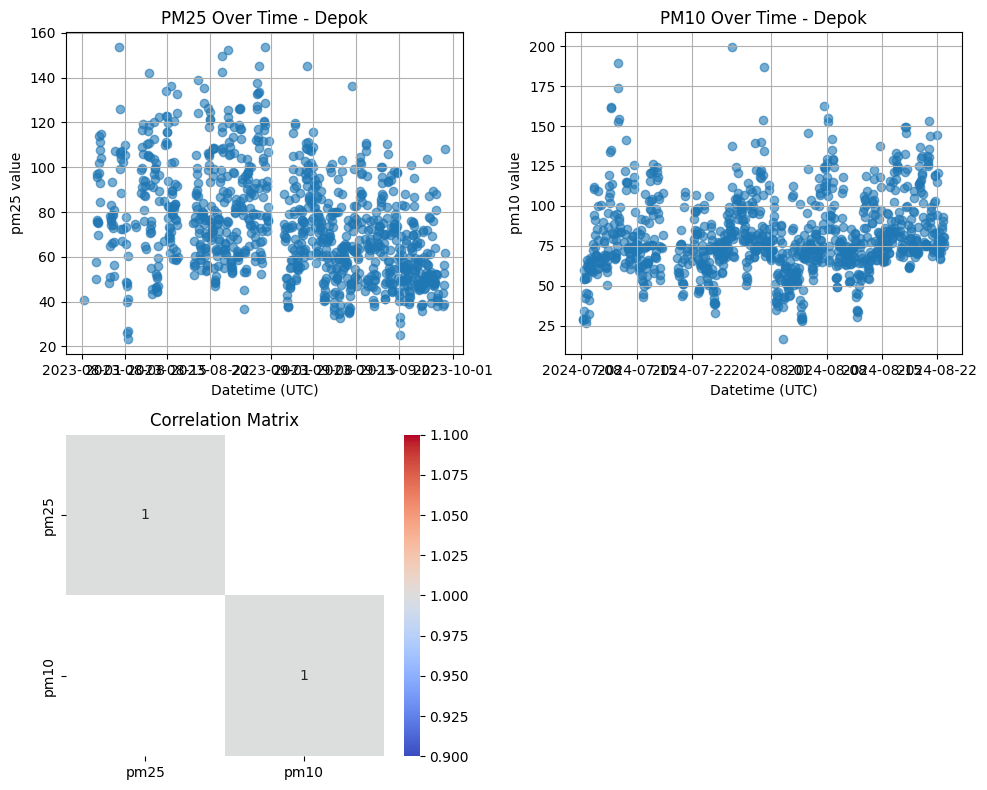

========== City: Hanoi ==========

Banyak data dari available_pollutants:
pm25    1000
pm10    1000
o3      1000
no2     1000
so2     1000
dtype: int64
Banyak null dari available_pollutants:
pm25    35
pm10    35
o3      35
no2     35
so2     35
dtype: int64


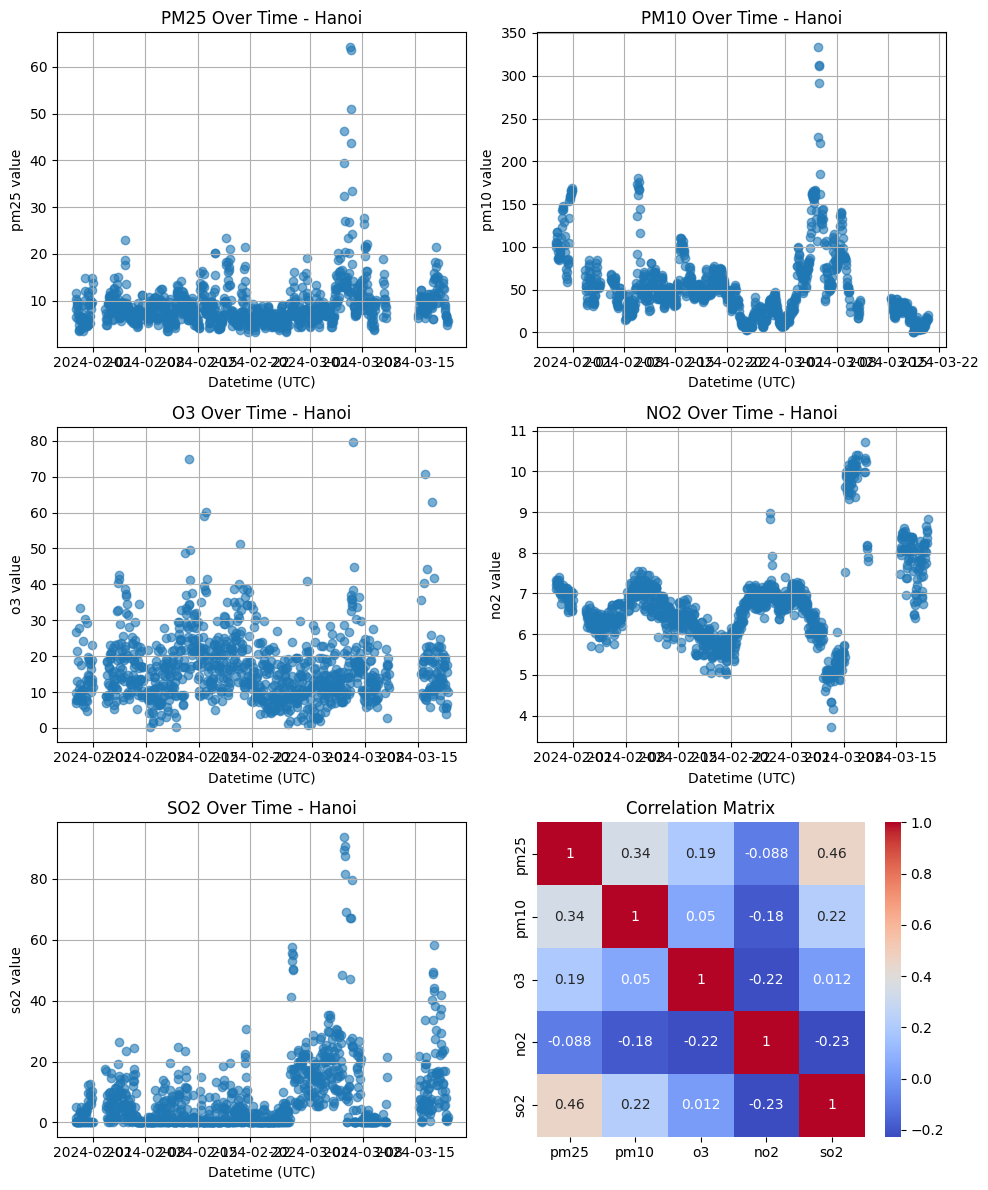

========== City: London ==========

Banyak data dari available_pollutants:
pm25    1000
pm10    1000
o3      1000
no2     1000
so2     1000
dtype: int64
Banyak null dari available_pollutants:
pm25    1067
pm10    1067
o3      1067
no2     1067
so2     1067
dtype: int64


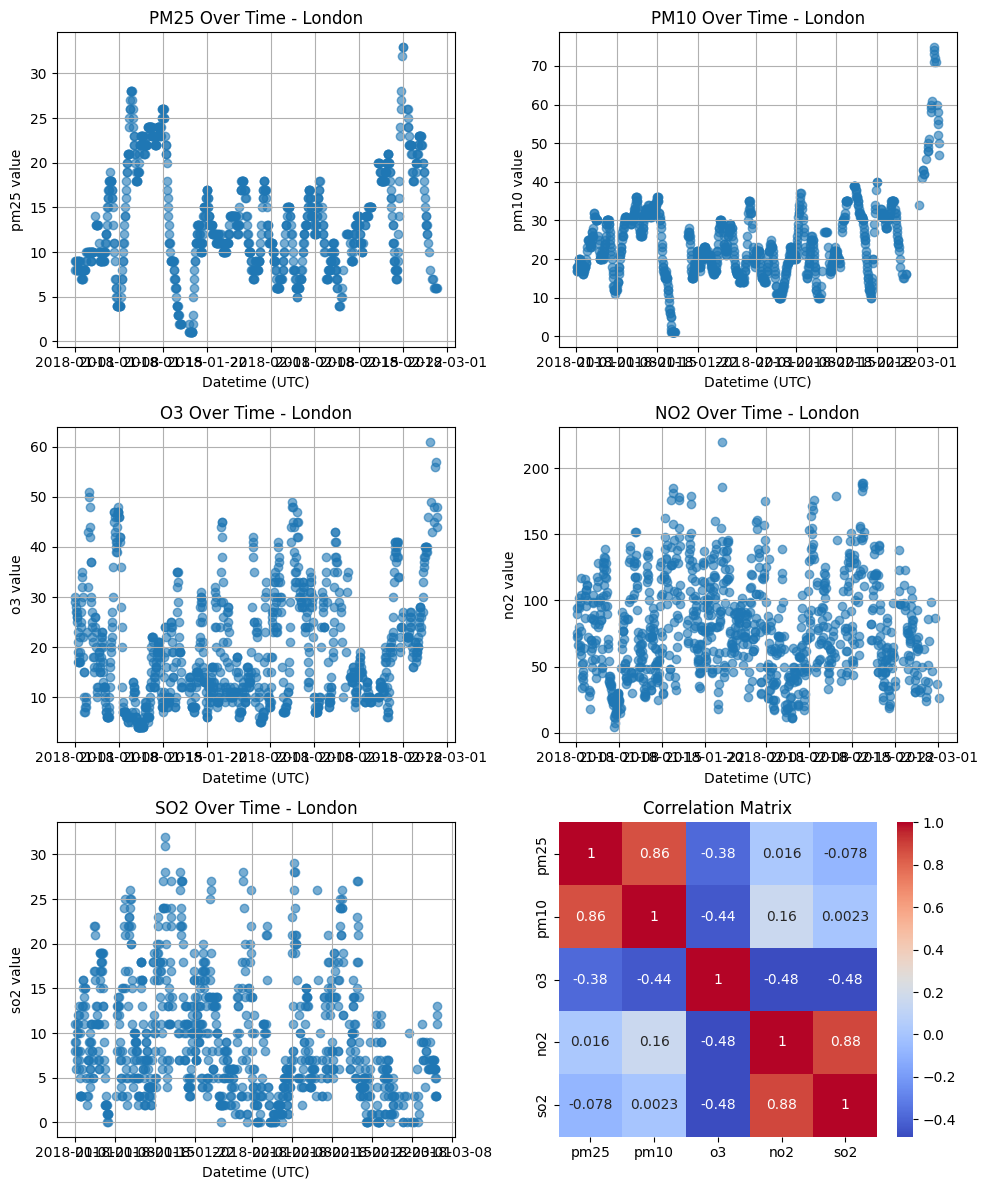

========== City: Madrid ==========

Banyak data dari available_pollutants:
pm25    1000
pm10    1000
o3      1000
no2     1000
so2     1000
dtype: int64
Banyak null dari available_pollutants:
pm25    1174
pm10    1174
o3      1174
no2     1174
so2     1174
dtype: int64


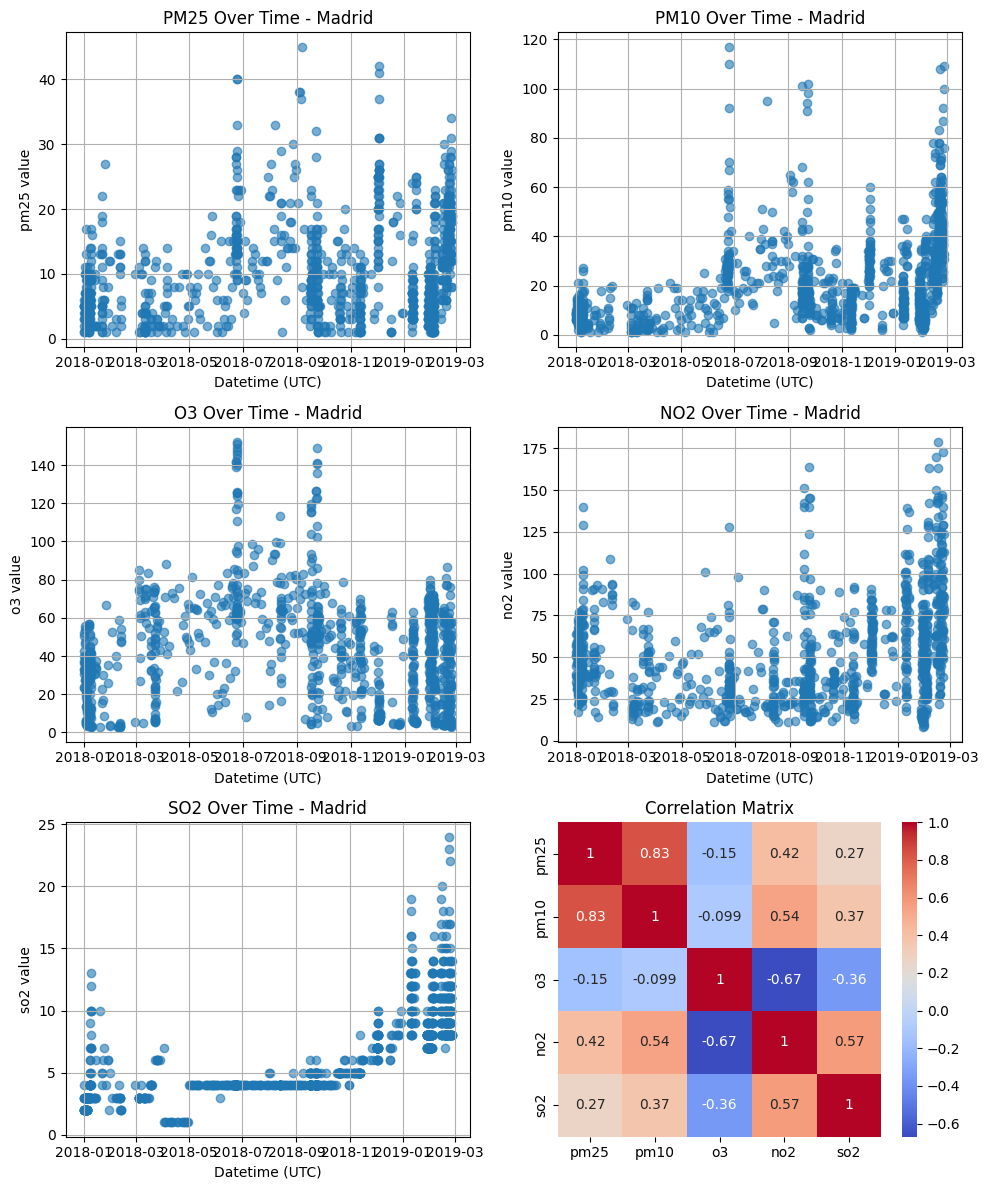

========== City: Napoli ==========

Banyak data dari available_pollutants:
pm25    1000
pm10    1000
no2     1000
so2     1000
dtype: int64
Banyak null dari available_pollutants:
pm25    148
pm10    148
no2     148
so2     148
dtype: int64


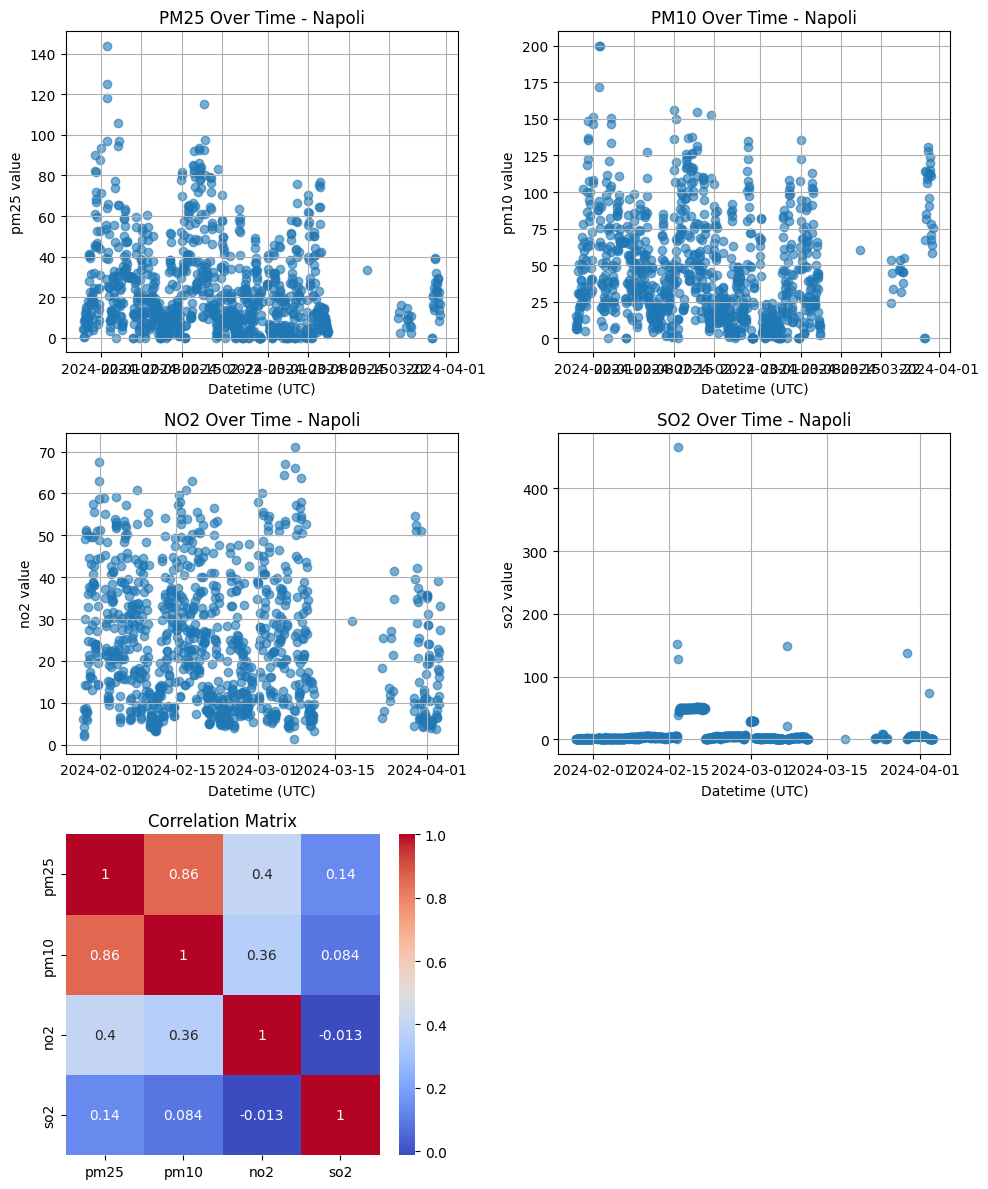

========== City: New Delhi ==========

Banyak data dari available_pollutants:
pm25    2000
pm10    2000
o3      2000
no2     2000
so2     2000
dtype: int64
Banyak null dari available_pollutants:
pm25    572
pm10    572
o3      572
no2     572
so2     572
dtype: int64


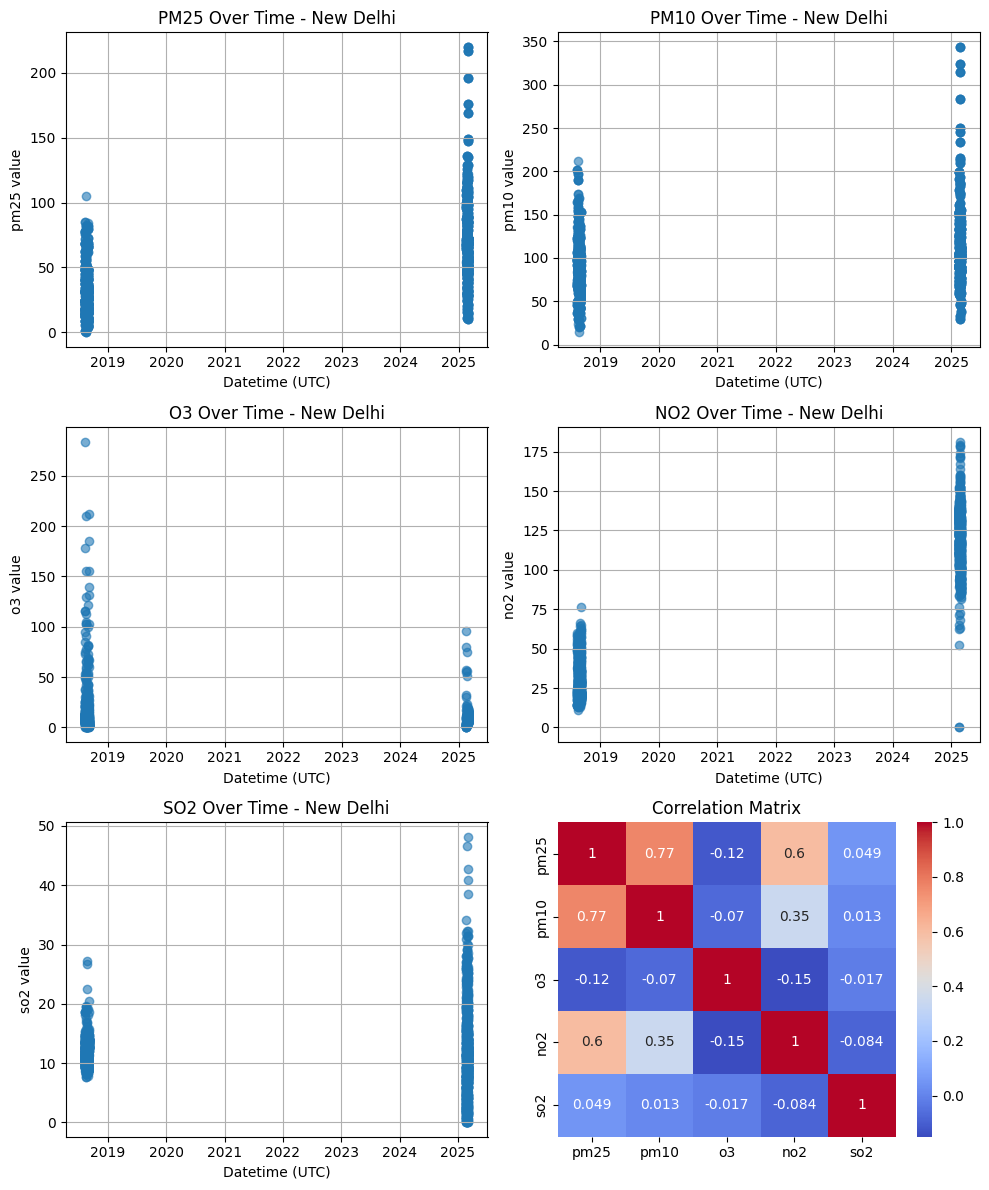

========== City: New Jersey ==========

Banyak data dari available_pollutants:
pm25    1000
o3      1000
no2     1000
so2     1000
dtype: int64
Banyak null dari available_pollutants:
pm25    2085
o3      2085
no2     2085
so2     2085
dtype: int64


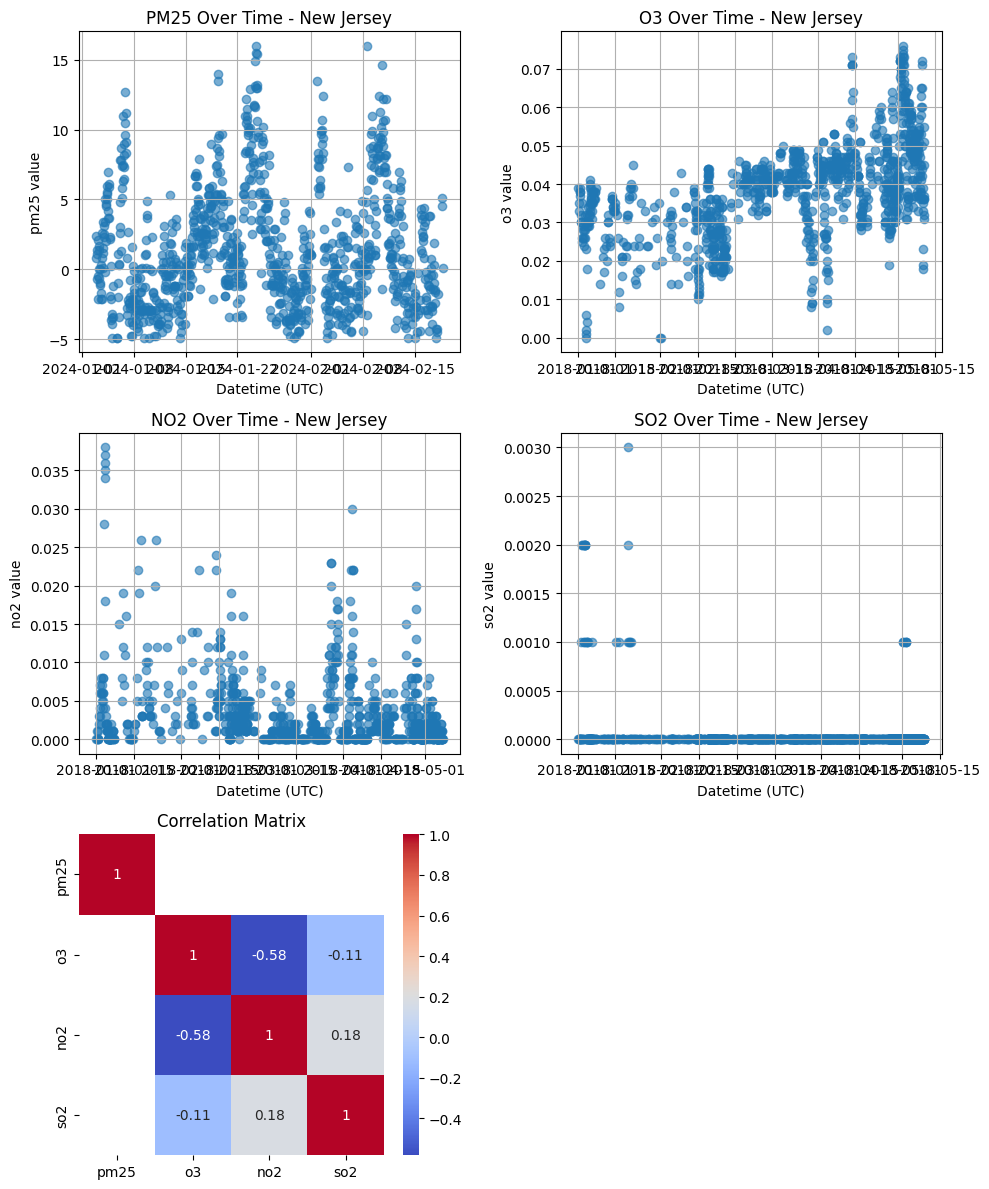

========== City: Paris ==========

Banyak data dari available_pollutants:
pm25    1000
pm10    1000
o3      1000
no2     1000
so2     1000
dtype: int64
Banyak null dari available_pollutants:
pm25    1121
pm10    1121
o3      1121
no2     1121
so2     1121
dtype: int64


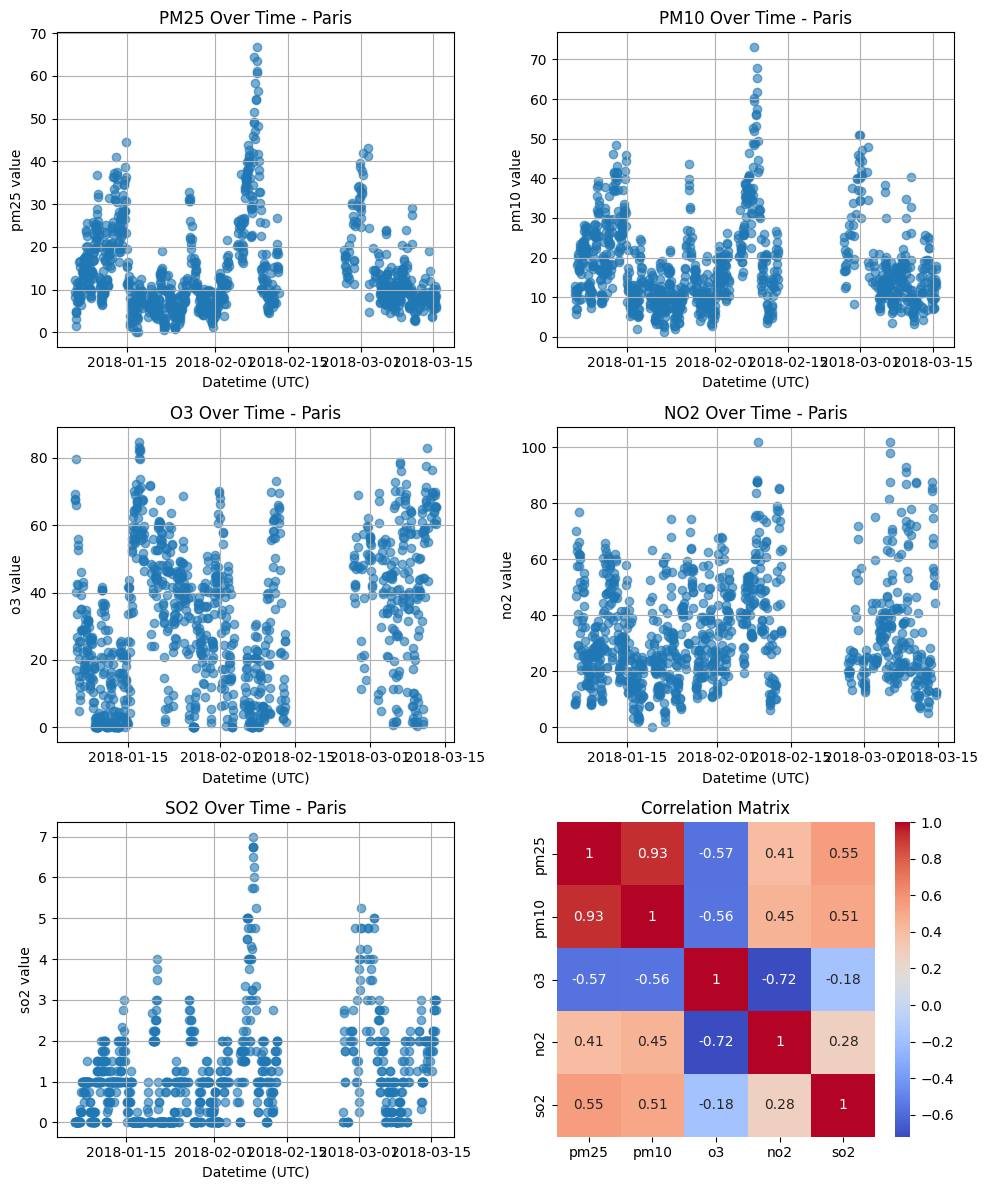

========== City: Riverside ==========

Banyak data dari available_pollutants:
pm25    1000
pm10    1000
o3      1000
no2     1000
so2     1000
dtype: int64
Banyak null dari available_pollutants:
pm25    1125
pm10    1125
o3      1125
no2     1125
so2     1125
dtype: int64


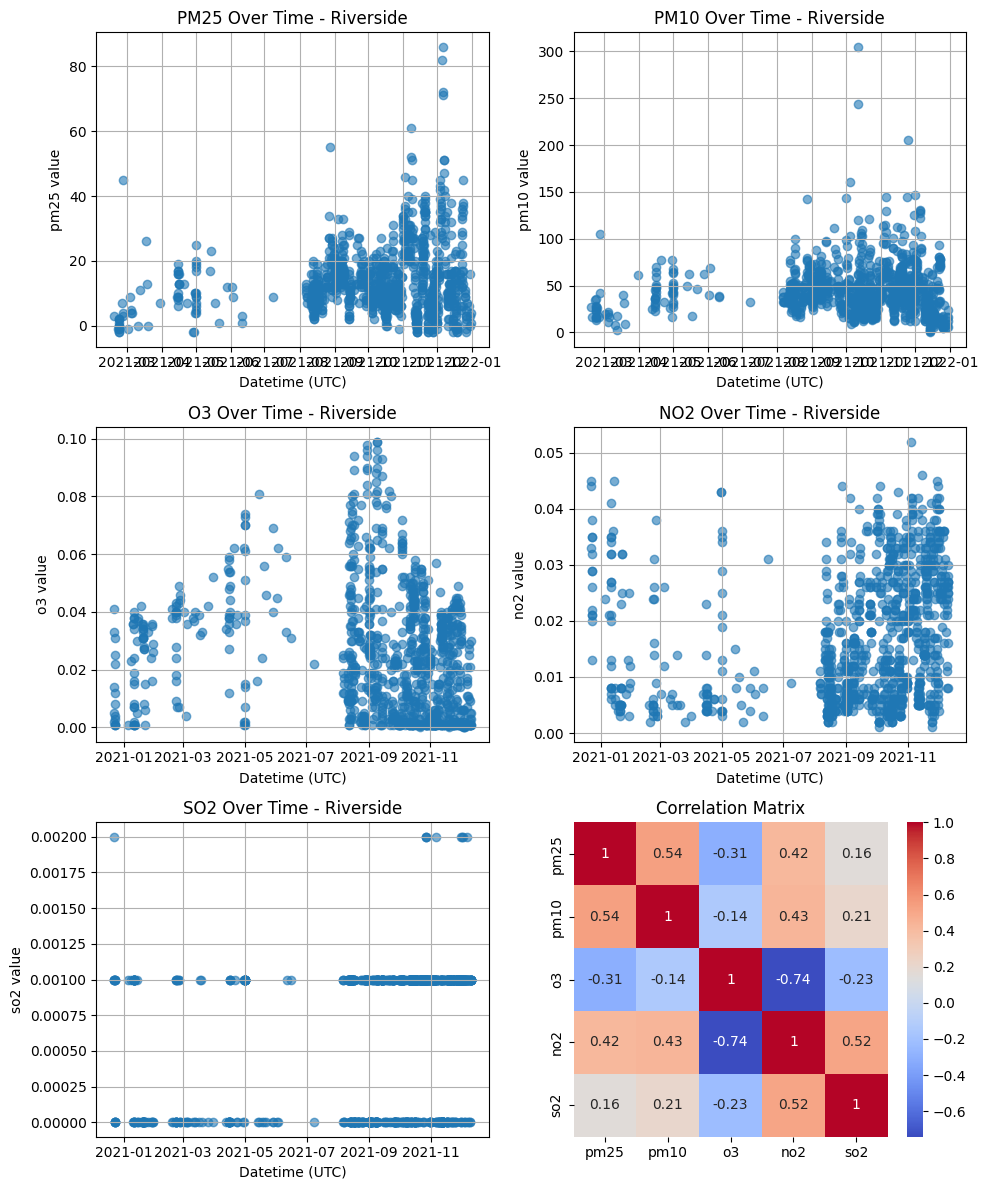

In [6]:
# Required for inline plotting in Jupyter
%matplotlib inline

# Define the path to the data directory
data_dir = "../data_processed/"

# List all files in the data directory
files = os.listdir(data_dir)
print(f"Files in {data_dir}: {files}\n\n")

cities = [file[:-14] for file in files if file.endswith('.csv')]

for city in cities:
    print(f"========== City: {city} ==========\n")
    try:
        df_wide = pd.read_csv(os.path.join(data_dir, f"{city}_processed.csv"), parse_dates=['datetimeUtc'])
        df_wide['datetimeUtc'] = pd.to_datetime(df_wide['datetimeUtc'])

        # Tentukan polutan-polutan yang ada pada data suatu kota
        pollutant_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2']
        available_pollutants = [col for col in pollutant_cols if col in df_wide.columns]
        
        print("Banyak data dari available_pollutants:")
        print(df_wide[available_pollutants].count())
        print("Banyak null dari available_pollutants:")
        print(df_wide[available_pollutants].isnull().sum())

        all_cols = available_pollutants
        n = len(all_cols)
        add_corr_matrix = True

        if n == 0:
            print(f"No pollutant data available for {city}")
        else:
            total_plots = n + (1 if add_corr_matrix else 0)
            cols = 2
            rows = math.ceil(total_plots / cols)

            fig, axes = plt.subplots(rows, cols, figsize=(10, 4 * rows), sharex=False)
            axes = axes.flatten()

            # Plot setiap polutan pada subplot yang berbeda
            for i, col in enumerate(all_cols):
                axes[i].scatter(df_wide['datetimeUtc'], df_wide[col], color='tab:blue', alpha=0.6)
                axes[i].set_title(f"{col.upper()} Over Time - {city}")
                axes[i].set_xlabel("Datetime (UTC)")
                axes[i].set_ylabel(f"{col} value")
                axes[i].grid(True)

            # Plot correlation matrix pada subplot terakhir 
            if add_corr_matrix:
                corr = df_wide[available_pollutants].corr()
                sns.heatmap(corr, annot=True, cmap='coolwarm', ax=axes[n])
                axes[n].set_title("Correlation Matrix")

            # Sembunyikan subplot yang tidak digunakan
            for j in range(n + 1, len(axes)):
                fig.delaxes(axes[j])

            fig.tight_layout()
            plt.show()

    except Exception as e:
        print(f"Could not process file {city}.csv: {e}")

## Data Preprocessing 2

### Pembersihan Dataset

Supaya data dapat digunakan untuk training, kolom-kolom data harus berupa feature dan target. Langkah selanjutnya pada preprocessing data adalah untuk menghapus kolom-kolom non-feature dan melihat bentuknya. Selain itu, kota-kota dengan anomali data yang besar juga tidak perlu dipilih.

Fitur: $\text{PM}_{2.5}$, $\text{PM}_{10}$, $\text{O}_{3}$, $\text{NO}_{2}$, $\text{SO}_{2}$

Kota: Hanoi, London, Madrid, Napoli, Paris

Kemudian, data kota-kota tersebut digabung (merge) menjadi satu file memanjang secara row.

In [7]:
# Define the path to the data directory
data_dir = os.path.abspath("../data_processed/")

# List all CSV files in the data directory
files = [file for file in os.listdir(data_dir) if file.endswith('.csv')]
print(f"CSV files in {data_dir}: {files}\n")

# Columns to drop
columns_to_drop = ['location_id', 'location_name', 'datetimeUtc', 'latitude', 'longitude', 'relativehumidity', 'temperature']
pollutant_cols = ['pm25', 'pm10', 'o3', 'no2', 'so2']

# Pilih kota dengan anomali yang dapat ditoleransi
cities = ['Hanoi', 'London', 'Madrid', 'Napoli', 'Paris']

# Initialize an empty DataFrame for merging with columns set to pollutant_cols
df_merged = pd.DataFrame(columns=pollutant_cols)

# Process each file
for file in files:
    if file[:-14] not in cities:
        continue
    try:        
        file_path = os.path.join(data_dir, file)
        df_wide = pd.read_csv(file_path, parse_dates=['datetimeUtc'])
        
        # Drop specified columns
        df_wide.drop(columns=columns_to_drop, inplace=True, errors='ignore')
        
        # Align columns and concatenate to the merged DataFrame, filling missing values with NaN
        df_wide = df_wide.reindex(columns=pollutant_cols, fill_value=pd.NA)
        df_merged = pd.concat([df_merged, df_wide], ignore_index=True)
        
    except Exception as e:
        print(f"Could not process file {file}: {e}")

# Optional: Save the merged DataFrame to a CSV file
data_merged_dir = os.path.abspath("../data_merged/")
output_path = os.path.join(data_merged_dir, "merged_data.csv")
df_merged.to_csv(output_path, index=False)
print(f"Merged data saved to {output_path}")

CSV files in d:\Kulyah\smt-4\ai\ai-project-25\data_processed: ['Depok_processed.csv', 'Hanoi_processed.csv', 'London_processed.csv', 'Madrid_processed.csv', 'Napoli_processed.csv', 'New Delhi_processed.csv', 'New Jersey_processed.csv', 'Paris_processed.csv', 'Riverside_processed.csv']

Merged data saved to d:\Kulyah\smt-4\ai\ai-project-25\data_merged\merged_data.csv


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_116032\3025404647.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_merged = pd.concat([df_merged, df_wide], ignore_index=True)
C:\Users\Lenovo\AppData\Local\Temp\ipykernel_116032\3025404647.py:31: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_merged = pd.concat([df_merged, df_wide], ignore_index=True)


Lihat bentuk/deskripsi data serta jumlah data null.

In [11]:
print("Raw merged data description:")
print(df_merged.describe())
print("\nNull values:")
print(df_merged.isnull().sum())

Raw merged data description:
              pm25         pm10           o3          no2          so2
count  5000.000000  5000.000000  4000.000000  5000.000000  5000.000000
mean     14.251662    32.611116    27.496982    39.336662     6.812366
std      13.159165    29.949532    21.954612    35.009612    12.290853
min       0.000000     0.000000     0.000000     0.000000     0.000000
25%       6.747500    13.340000    11.000000     9.750000     1.000000
50%      10.280000    23.465000    21.000000    29.000000     3.900000
75%      17.085000    40.265000    40.182500    55.030000     8.000000
max     143.860000   334.010000   152.300000   220.000000   465.520000

Null values:
pm25    3545
pm10    3545
o3      4545
no2     3545
so2     3545
dtype: int64


Bersihkan data dari nilai-nilai NaN dengan menghapusnya. Simpan data baru pada file CSV dengan nama "`merged_cleaned_data.csv`".

DataFrame yang siap digunakan bernama `df_merged_cleaned` yang akan digunakan seterusnya pada pelatihan dan pengujian model.
Sedangkan kolom-kolom yang akan digunakan sebagai feature ada pada list `pollutant_cols`.

### Generate Target Label dengan Thresholding

In [12]:
# Remove rows with NaN values
df_merged_cleaned = df_merged.dropna()

# Display the cleaned DataFrame
print("Cleaned merged data description:")
print(df_merged_cleaned.describe())
print("\nNull values after cleaning:")
print(df_merged_cleaned.isnull().sum())

print("\nSample cleaned data:")
print(df_merged_cleaned.head())

# Optional: Save the merged DataFrame to a CSV file
data_merged_dir = os.path.abspath("../data_merged/")
output_path = os.path.join(data_merged_dir, "merged_cleaned_data.csv")
df_merged_cleaned.to_csv(output_path, index=False)
print(f"Merged data saved to {output_path}")

Cleaned merged data description:
              pm25         pm10           o3          no2          so2
count  3565.000000  3565.000000  3565.000000  3565.000000  3565.000000
mean     11.798331    30.080157    26.786104    43.188460     6.218149
std       7.818181    28.151126    21.881116    37.775049     7.843082
min       0.000000     1.000000     0.000000     0.000000     0.000000
25%       6.780000    13.200000    10.800000     8.020000     1.000000
50%      10.000000    22.000000    20.000000    33.000000     4.000000
75%      15.000000    35.000000    38.000000    64.000000     8.990000
max      66.850000   334.010000   152.300000   220.000000    93.880000

Null values after cleaning:
pm25    0
pm10    0
o3      0
no2     0
so2     0
dtype: int64

Sample cleaned data:
    pm25    pm10     o3   no2   so2
0   8.15   99.63   7.79  7.20  0.00
1   6.55  103.24   7.07  7.32  0.00
2  10.45  105.75   9.63  7.12  4.98
3  11.54  112.08  26.66  7.26  1.30
4   8.90  117.49  21.41  7.26  0.0

## Pengembangan Model

Membuat program untuk generate decision tree berdasarkan input dataset.

In [13]:
# Import numpy untuk operasi angka pada model
import numpy as np

### Node

Node bisa berupa decision node (pertengahan tree) ataupun leaf node (akhir tree yang mengandung keputusan akhir).

In [14]:
class Node():
    """*Class* untuk menyimpan informasi tentang *node* dalam *decision tree*.
    
    **Constructor**:
        `__init__(self, feature_index = None, threshold = None, left = None, right = None, info_gain = None, value = None)`
    """
    def __init__(self, feature_index = None, threshold = None, left = None, right = None, info_gain = None, value = None):
        # Decision node
        self.feature_index = feature_index
        self.threshold = threshold
        self.left = left
        self.right = right
        self.info_gain = info_gain
        
        # Leaf node
        self.value = value

### Tree Generation

Kelas ini merupakan representasi pohon yang terdiri atas node dan memiliki berbagai fungsi untuk data fitting dan fungsi dependensinya (splitting, menghitung nilai leaf value, dll).

In [17]:
class DecisionTreeClassifier():
    """*Class* untuk melakukan klasifikasi dengan model *decision tree*.
    
    **Constructor**:
        `__init__(self, min_samples_split = 2, max_depth = 10)`
    
    **Method**:
        `fit(self, X, y)`: Melakukan fitting model
        `predict(self, X)`: Memprediksi sebuah dataset
        `make_prediction(self, x, tree)`: Melakukan prediksi hanya untuk sebuah data
        `print_tree(self, node=None, depth=0)`: Mencetak decision tree
    """
    def __init__(self, min_samples_split = 2, max_depth = 10):
        self.root = None
        
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        
    def build_tree(self, dataset, curr_depth = 0):
        """Membuat decision tree secara rekursif.

        Args:
            dataset (_type_): Dataset yang akan digunakan untuk membangun tree.
            curr_depth (int, optional): Kedalaman saat ini dari tree. Defaults to 0.
        """
        
        X, y = dataset[:, :-1], dataset[:, -1]
        num_samples, num_features = np.shape(X)
        
        # Nilai decision node
        if num_samples >= self.min_samples_split and curr_depth < self.max_depth:
            best_split = self.get_best_split(dataset, num_samples, num_features)
            if best_split["info_gain"] > 0:
                left_subtree = self.build_tree(best_split["left"], curr_depth + 1)
                right_subtree = self.build_tree(best_split["right"], curr_depth + 1)
                return Node(best_split["feature_index"], best_split["threshold"], left_subtree, right_subtree, best_split["info_gain"])
        
        # Nilai leaf node
        leaf_value = self.calculate_leaf_value(y)
        return Node(value = leaf_value)
    
    def get_best_split(self, dataset, num_features):
        """Mencari split terbaik dari suatu dataset.

        Args:
            dataset (_type_): Dataset untuk mencari split terbaik.
            num_features (_type_): Banyak fitur dalam dataset.
        """
        
        best_split = {}
        max_info_gain = -float("inf")
        
        for feature_index in range(num_features):
            feature_values = dataset[:, feature_index]
            possible_thresholds = np.unique(feature_values)
            
            for threshold in possible_thresholds:
                left_subtree, right_subtree = self.split(dataset, feature_index, threshold)
                
                if len(left_subtree) > 0 and len(right_subtree) > 0:
                    y = dataset[:, -1]
                    curr_info_gain = self.information_gain(y, left_subtree[:, -1], right_subtree[:, -1], mode='gini')
                    
                    if curr_info_gain > max_info_gain:
                        max_info_gain = curr_info_gain
                        best_split["feature_index"] = feature_index
                        best_split["threshold"] = threshold
                        best_split["left"] = left_subtree
                        best_split["right"] = right_subtree
                        best_split["info_gain"] = max_info_gain
        
        return best_split
    
    def split(self, dataset, feature_index, threshold):
        """Membagi data menjadi dua subset kiri dan kanan berdasarkan threshold.

        Args:
            dataset (_type_): Dataset untuk membagi data.
            feature_index (_type_): Index fitur yang akan digunakan untuk membagi data.
            threshold (_type_): Nilai threshold.
        """
        
        left_subtree = np.array([row for row in dataset if row[feature_index] <= threshold])
        right_subtree = np.array([row for row in dataset if row[feature_index] > threshold])
        
        return left_subtree, right_subtree
    
    def information_gain(self, parent, left_child, right_child, mode='entropy'):
        """Menghitung information gain dari suatu split menggunakan entropi atau gini index.
        Args:
            parent (_type_): Dataset sebelum split.
            left_child (_type_): Dataset setelah split ke kiri.
            right_child (_type_): Dataset setelah split ke kanan.
            mode (str, optional): Mode perhitungan (`entropy` atau `gini`). Defaults to `entropy`.
        """
                
        weight_left = len(left_child) / len(parent)
        weight_right = len(right_child) / len(parent)
        
        if mode == 'gini':
            gain = self.gini(parent, left_child, right_child, weight_left, weight_right)
        else:
            gain = self.entropy(parent, left_child, right_child, weight_left, weight_right)
        
        return gain
    
    def entropy(self, y):
        """Menghitung entropi label.

        Args:
            y (_type_): Label dari dataset.
        """
        
        class_labels = np.unique(y)
        entropy = 0
        
        for label in class_labels:
            prob = len(y[y == label]) / len(y)
            entropy -= prob * np.log2(prob)
        
        return entropy
    
    def gini_index(self, y):
        """Menghitung gini index label.

        Args:
            y (_type_): Label dari dataset.
        """
        
        class_labels = np.unique(y)
        gini = 1
        
        for label in class_labels:
            prob = len(y[y == label]) / len(y)
            gini -= prob ** 2
        
        return gini
    
    def calculate_leaf_value(self, y):
        """Menghitung nilai leaf node.

        Args:
            y (_type_): Label dari dataset.
        """
        
        Y = list(y)
        return max(Y, key=Y.count)
    
    def print_tree(self, node=None, depth=0):
        """Mencetak decision tree.

        Args:
            node (_type_, optional): Node yang akan dicetak. Defaults to None.
            depth (int, optional): Kedalaman saat ini dari tree. Defaults to 0.
        """
        
        if node is None:
            node = self.root
        
        if node.value is not None:
            print(f"{' ' * depth * 2}Leaf Node: {node.value}")
            return
        
        print(f"{' ' * depth * 2}Node: [Feature Index: {node.feature_index}, Threshold: {node.threshold}]")
        self.print_tree(node.left, depth + 1)
        self.print_tree(node.right, depth + 1)
        
    def fit(self, X, y):
        """Melakukan fitting model dengan dataset yang diberikan.

        Args:
            X (_type_): _Dataframe_ fitur dari dataset.
            y (_type_): _Label_ dari dataset.
        """
        
        dataset = np.column_stack((X, y))
        self.root = self.build_tree(dataset)
        
    def predict(self, X):
        """Memprediksi sebuah dataset berdasarkan model yang telah dilatih.

        Args:
            X (_type_): _Dataframe_ fitur dari dataset yang akan diprediksi.
        
        Returns:
            _type_: _Array_ dari hasil prediksi.
        """
        
        predictions = [self._predict(x, self.root) for x in X]
        return np.array(predictions)
    
    def make_prediction(self, x, tree):
        """Melakukan prediksi hanya untuk sebuah data.

        Args:
            X (_type_): _description_
            tree (_type_): _description_
            
        Returns:
            _type_: Hasil prediksi untuk sebuah data.
        """
        
        if tree.value is not None:
            return tree.value
        feature_val = x[tree.feature_index]
        if feature_val <= tree.threshold:
            return self.make_prediction(x, tree.left)
        else:
            return self.make_prediction(x, tree.right)

## Model Training dan Validasi

### Train, Test, Val Splitting

Pisah dataset "`merged_cleaned_data.csv`" menjadi 3 bagian: train, test, dan validation dengan proporsi 70%, 15%, dan 15%.

DataFrame: `df_merged_cleaned`

Columns: `pollutant_cols`

In [ ]:
RANDOM_STATE = 42

# Shuffle dataset dengan random seed
# Fixed random state untuk memastikan konsistensi
df_merged_cleaned = df_merged_cleaned.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

# Feature dan target dataset
X = df_merged_cleaned[pollutant_cols].values
y = df_merged_cleaned['label'].values



## Model Testing dan Result Validation

## Kesimpulan